# Bell circuit and SWAP test

## 1. Computational basis and normalization — Task 1.1

In [2]:
import numpy as np
import math
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.circuit import QuantumRegister
from qiskit.circuit import ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

DTYPE = np.complex128

def ket00():
    """Return |00> as a length‑4 complex column vector."""
    v = np.zeros(4, dtype=DTYPE)
    v[0] = 1.0
    return v

def normalize(v: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(v)
    if n == 0:
        raise ValueError("Zero vector cannot be normalized.")
    return v / n

# Example
psi = ket00()
assert np.isclose(np.linalg.norm(psi), 1.0)

**Task 1.1: What basis ordering is used, and how are bitstrings mapped to indices?**

We use the computational basis $|q_0q_1\rangle$, with $q_0$ as the most significant bit. The index is $i=2q_0+q_1$, so $|00\rangle,|01\rangle,|10\rangle,|11\rangle$ correspond to indices $0,1,2,3$.

`ket00()` returns the one dimensional NumPy array `[1, 0, 0, 0]` with complex double. It represents a ket and its norm is one. `normalize(v)` divides each amplitude by $\|v\|$, enforcing $\sum_i |v_i|^2=1$, and rejects the zero vector because it cannot represent a normalized quantum state.

## 2. Gates and their application to the state — Task 1.2

In [4]:
# 1‑qubit and 2‑qubit gate definitions (matrix form)
I2 = np.array([[1, 0], [0, 1]], dtype=DTYPE)
H  = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=DTYPE)

# CNOT with control = q0 (MSB), target = q1 (LSB) in basis |q0 q1>
CNOT_01 = np.array([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,0,1],
    [0,0,1,0]
], dtype=DTYPE)

# Expand a 1‑qubit unitary U to a 2‑qubit operator acting on target qubit t in |q0 q1> order
# t = 0 applies to q0 (MSB); t = 1 applies to q1 (LSB)

def expand_1q(U: np.ndarray, t: int) -> np.ndarray:
    if t == 0:   # act on q0 (MSB)
        return np.kron(U, I2)
    elif t == 1: # act on q1 (LSB)
        return np.kron(I2, U)
    else:
        raise ValueError("target index must be 0 or 1")

# Apply a gate matrix to a state vector

def apply(U: np.ndarray, psi: np.ndarray) -> np.ndarray:
    return U @ psi

# Quick unit tests
assert np.allclose(H.conj().T @ H, I2)
assert np.allclose(CNOT_01.conj().T @ CNOT_01, np.eye(4))

**Task 1.2: Briefly justify your control/target convention for CNOT and how it matches the basis ordering**

The first qubit $q_0$ is the control and $q_1$ is the target. Therefore CNOT leaves $|00\rangle$ and $|01\rangle$ unchanged, and exchanges $|10\rangle$ with $|11\rangle$. These are exactly the mappings represented by the columns of `CNOT_01`: indices 0 and 1 are fixed, while indices 2 and 3 are exchanged.

## 3. Bell circuit — Task 1.3

In [5]:
def bell_state() -> np.ndarray:
    psi = ket00()
    # H on q0 (MSB), then CNOT(control=q0, target=q1)
    psi = apply(expand_1q(H, t=0), psi)
    psi = apply(CNOT_01, psi)
    return normalize(psi)

psi_bell = bell_state()
print("Bell state vector:", np.round(psi_bell, 6))
# Expected amplitudes (up to a global phase): [1/√2, 0, 0, 1/√2]

Bell state vector: [0.707107+0.j 0.      +0.j 0.      +0.j 0.707107+0.j]


In [6]:
assert np.allclose(psi_bell, [1/np.sqrt(2), 0, 0, 1/np.sqrt(2)])

**Task 1.3 — Print the final state and confirm it matches ( |00> + |11> ) / √2 up to global phase.**

The printed vector is `[0.707107+0.j, 0.+0.j, 0.+0.j, 0.707107+0.j]`, rounded to six decimal places. The transformations are

$$
|00\rangle \xrightarrow{H\otimes I}
\frac{|00\rangle+|10\rangle}{\sqrt 2}
\xrightarrow{\mathrm{CNOT}_{0\to1}}
\frac{|00\rangle+|11\rangle}{\sqrt 2}=|\Phi^+\rangle.
$$

## 4. Measurements and histogram — Task 1.4

{'00': 4983, '01': 0, '10': 0, '11': 5017}


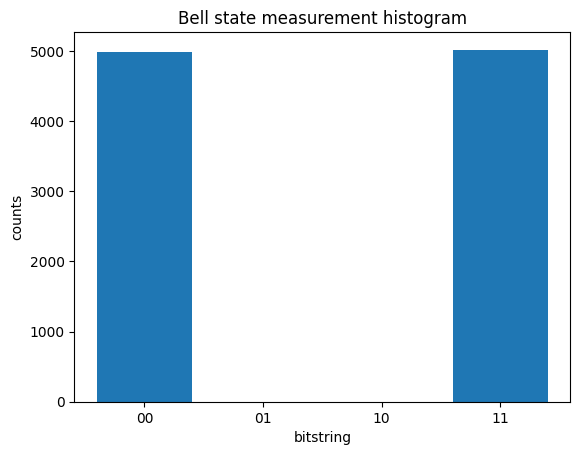

In [7]:
import matplotlib.pyplot as plt

BITSTR = ["00","01","10","11"]

def sample_bitstrings(psi: np.ndarray, shots: int = 10_000, seed: int = 7):
    rng = np.random.default_rng(seed)
    probs = np.abs(psi)**2
    idx = rng.choice(4, size=shots, p=probs)
    return idx

# Sample from Bell state
shots = 10_000
idx = sample_bitstrings(psi_bell, shots=shots)

# Make histogram
counts = {b: int(np.sum(idx == i)) for i, b in enumerate(BITSTR)}
print(counts)
plt.bar(counts.keys(), counts.values())
plt.xlabel("bitstring"); plt.ylabel("counts"); plt.title("Bell state measurement histogram")
plt.show()

**Task 1.4 — Do the counts match expectations within sampling error?**

Yes. The observed counts are:

| Bitstring | Theoretical probability | Expected count | Observed count |
| --- | ---: | ---: | ---: |
| 00 | 0.5 | 5000 | 4983 |
| 01 | 0 | 0 | 0 |
| 10 | 0 | 0 | 0 |
| 11 | 0.5 | 5000 | 5017 |

The counts for `00` and `11` are close to the expected equal split. Small deviations are normal when sampling a finite number of measurements. Outcomes `01` and `10` are absent, as expected.

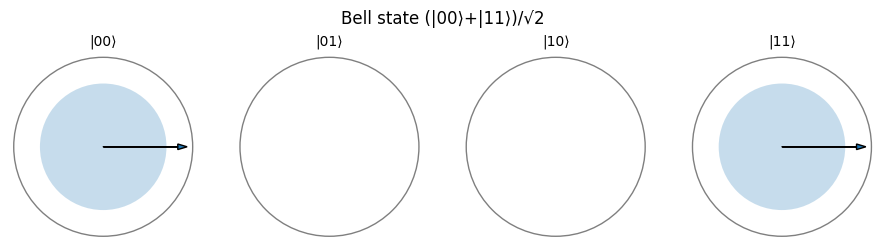

In [8]:
def sv_from_circ(circ: QuantumCircuit) -> np.ndarray:
    sv = Statevector(circ)
    return np.asarray(sv, dtype=np.complex128)

class QubitSystem:
    def __init__(self, statevector: np.ndarray, label: str = "Qubit System"):
        self.label = label
        self.set_statevector(statevector)

    def set_statevector(self, statevector: np.ndarray):
        sv = np.asarray(statevector, dtype=np.complex128)
        if sv.ndim != 1:
            raise ValueError("Statevector must be 1D.")
        n_states = sv.size
        if n_states == 0 or not np.all(np.isfinite(sv)):
            raise ValueError("Statevector must be nonempty and finite.")
        n_qubits = int(round(math.log2(n_states)))
        if 2**n_qubits != n_states:
            raise ValueError("Length must be a power of 2.")
        # Defensive normalization (harmless if already normalized)
        norm = np.linalg.norm(sv)
        if norm == 0 or not np.isfinite(norm):
            raise ValueError("Statevector must have a finite, nonzero norm.")
        sv = sv / norm

        self.n_qubits = n_qubits
        self.n_states = n_states
        self.amps  = sv
        self.prob  = np.abs(sv)**2
        self.phase = np.angle(sv)

    def viz_circle(self, max_cols: int = 8, figsize_scale: float = 2.3):
        cols = max(1, min(max_cols, self.n_states))
        rows = int(math.ceil(self.n_states / cols))

        fig, axes = plt.subplots(
            rows, cols, squeeze=False,
            figsize=(cols*figsize_scale, rows*(figsize_scale+0.2))
        )

        def bitstr(i: int, n: int) -> str:
            return format(i, f"0{n}b")

        for idx in range(rows * cols):
            r, c = divmod(idx, cols)
            ax = axes[r, c]
            ax.set_aspect("equal")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.axis("off")

            if idx >= self.n_states:
                ax.set_visible(False)
                continue

            # Outer reference circle
            ax.add_patch(plt.Circle((0.5, 0.5), 0.48, fill=False, lw=1.0, alpha=0.5))

            # Filled disk: radius ∝ sqrt(probability) so area ∝ probability
            radius = 0.48 * np.sqrt(self.prob[idx])
            ax.add_patch(plt.Circle((0.5, 0.5), radius, alpha=0.25))

            # Zero amplitudes have no defined phase.
            if self.prob[idx] > 0:
                angle = self.phase[idx]
                L = 0.45
                x2 = 0.5 + L * np.cos(angle)
                y2 = 0.5 + L * np.sin(angle)
                ax.arrow(0.5, 0.5, x2 - 0.5, y2 - 0.5,
                         head_width=0.03, head_length=0.05, length_includes_head=True)

            ax.set_title(f"|{bitstr(idx, self.n_qubits)}⟩", fontsize=10)

        fig.suptitle(self.label, fontsize=12)
        plt.tight_layout()
        plt.show()

QubitSystem(psi_bell, label="Bell state (|00⟩+|11⟩)/√2").viz_circle()

**Task 1.4:  How does the circle plot show two dominant components |00> and |11> and their relative phase?**

Each position represents one computational basis state. In `viz_circle`, the filled radius is proportional to $\sqrt{p_i}=|\psi_i|$, so the filled area is proportional to the probability $p_i$. The circles for $|00\rangle$ and $|11\rangle$ therefore have equal filled area, each representing probability $1/2$. The positions for $|01\rangle$ and $|10\rangle$ have zero filled area.
The arrows encode $\arg(\psi_i)$. Both nonzero Bell amplitudes are real and positive, so both arrows point to the right: their relative phase is zero. Zero amplitudes have no defined phase and are drawn without arrows. A global phase would rotate both nonzero arrows by the same amount without changing their relative phase or measurement probabilities. 

## 6. SWAP test: setup — Task 2

The objective is to infer the fidelity between two normalized pure one-qubit states and compare it with the direct inner product:

$$
F=|\langle\psi|\phi\rangle|^2,\qquad
P(1)=\frac{1-F}{2},\qquad F=1-2P(1).
$$

In [9]:
def expand_1q_n(U: np.ndarray, t: int, n: int) -> np.ndarray:
    op = np.array([[1]], dtype=U.dtype)
    for q in range(n):
        op = np.kron(op, U if q == t else I2)
    return op

# Apply CSWAP, with ancilla as control
P0 = np.array([[1,0],[0,0]], dtype=DTYPE)  # |0><0| on ancilla
P1 = np.array([[0,0],[0,1]], dtype=DTYPE)  # |1><1| on ancilla
SWAP_A0_B0 = np.array([
    [1,0,0,0],
    [0,0,1,0],
    [0,1,0,0],
    [0,0,0,1]
], dtype=DTYPE)  # SWAP on A0 and B0
CSWAP = (np.kron(P0, np.eye(4)) + np.kron(P1, SWAP_A0_B0)) # CSWAP with ancilla as control

In [ ]:
psi = np.array([1, 0], dtype=DTYPE)
phi = np.array([0, 1], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)
init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi))  
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()   # indices with output=1
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)

assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

######################
psi = np.array([1, 0], dtype=DTYPE)
phi = np.array([1, 0], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)

init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi))  
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()   
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)
assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

######################
psi = np.array([1, 1], dtype=DTYPE) / np.sqrt(2)
phi = np.array([1, 0], dtype=DTYPE)
assert np.isclose(np.linalg.norm(psi), 1.0)
assert np.isclose(np.linalg.norm(phi), 1.0)

init = np.kron(np.array([1,0], dtype=DTYPE), np.kron(psi, phi)) 
U_Ho = expand_1q_n(H, t=0, n=3)
state = U_Ho @ init
state = CSWAP @ state
state = U_Ho @ state

probs = np.abs(state)**2
prob_1 = probs[4:].sum()  
F_hat = 1 - 2*prob_1
F_exact = float(np.abs(np.vdot(psi/np.linalg.norm(psi), phi/np.linalg.norm(phi)))**2)
assert np.isclose(np.sum(np.abs(state)**2), 1.0)
assert np.isclose(F_hat, F_exact)
print(F_hat, F_exact)

**Task 2 — Report F_hat versus F_exact for at least three pairs.**

| Input psi | Input phi | P(output=1) | F_hat from SWAP test | F_exact from inner product |
| --- | --- | ---: | ---: | ---: |
| $\lvert 0\rangle$ | $\lvert 1\rangle$ | 0.5 | 0 | 0 |
| $\lvert 0\rangle$ | $\lvert 0\rangle$ | 0 | 1 | 1 |
| $\lvert +\rangle$ | $\lvert 0\rangle$ | 0.25 | 0.5 | 0.5 |

Values are rounded for readability. In the first case the printed `F_hat` is about $4.44\times10^{-16}$, which is numerical roundoff around zero. `np.vdot` conjugates the first vector, giving the correct complex inner product. The input and final-state normalization checks pass, as do all three fidelity comparisons.

**How does the output bit encode overlap?**

After H–CSWAP–H, the joint state is

$$
\frac{1}{2}|0\rangle\bigl(|\psi\rangle|\phi\rangle+|\phi\rangle|\psi\rangle\bigr)
+\frac{1}{2}|1\rangle\bigl(|\psi\rangle|\phi\rangle-|\phi\rangle|\psi\rangle\bigr)
$$

The probability of measuring 1 on the output qubit is $P(1)=(1-F)/2$. The larger the overlap, the less likely we are to measure 1. For the three pairs above, identical inputs give $P(1)=0$, orthogonal inputs give $P(1)=1/2$, and the partially overlapping states $|+\rangle$ and $|0\rangle$ give $P(1)=1/4$. A single measurement of 0 does not prove that the inputs are identical: the result can be obtained also with different states, since in that case the probability of obtaining 0 is different than zero.

## Bonus 1 — Basis-state comparison (Task B.1)

The reference register contains $|101\rangle$ (`k=5`). `build_swap_test(k)` prepares the test register in $|k\rangle$ and measures only the output of the three-pair SWAP test. 

In [10]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator


def fidelity(u, v):
    u = u / np.linalg.norm(u)
    v = v / np.linalg.norm(v)
    return float(np.abs(np.vdot(u, v))**2)


def build_swap_test(k):
    n = 3
    reference_k = 5  # |101>
    reference = QuantumRegister(n, "reference")
    test = QuantumRegister(n, "test")
    output = QuantumRegister(1, "output")
    result = ClassicalRegister(1, "result")
    circuit = QuantumCircuit(reference, test, output, result)

    for i in range(n):
        if (reference_k >> i) & 1:
            circuit.x(reference[i])
        if (k >> i) & 1:
            circuit.x(test[i])

    circuit.h(output[0])
    for i in range(n):
        circuit.ccx(output[0], reference[i], test[i])
        circuit.ccx(output[0], test[i], reference[i])
        circuit.ccx(output[0], reference[i], test[i])
    circuit.h(output[0])
    circuit.measure(output[0], result[0])
    return circuit


**B.1 — How is control distributed, and what is the exchange decomposition?**

The same `output[0]` controls all three matched register pairs. For each pair $(R_i,T_i)$, the code applies `CCX(output, R_i, T_i)`, `CCX(output, T_i, R_i)`, and `CCX(output, R_i, T_i)` in that order. If output is 0, all three gates act as identity. If output is 1, they reduce to the usual CX–CX–CX SWAP decomposition.

The circuit uses 7 qubits, 9 three-qubit CCX gates, 2 H gates, and one output measurement. 



```text
             ┌───┐     ┌───┐                                           
reference_0: ┤ X ├──■──┤ X ├──■────────────────────────────────────────
             └───┘  │  └─┬─┘  │       ┌───┐                            
reference_1: ───────┼────┼────┼────■──┤ X ├──■─────────────────────────
             ┌───┐  │    │    │    │  └─┬─┘  │       ┌───┐             
reference_2: ┤ X ├──┼────┼────┼────┼────┼────┼────■──┤ X ├──■──────────
             ├───┤┌─┴─┐  │  ┌─┴─┐  │    │    │    │  └─┬─┘  │          
     test_0: ┤ X ├┤ X ├──■──┤ X ├──┼────┼────┼────┼────┼────┼──────────
             └───┘└─┬─┘  │  └─┬─┘┌─┴─┐  │  ┌─┴─┐  │    │    │          
     test_1: ───────┼────┼────┼──┤ X ├──■──┤ X ├──┼────┼────┼──────────
             ┌───┐  │    │    │  └─┬─┘  │  └─┬─┘┌─┴─┐  │  ┌─┴─┐        
     test_2: ┤ X ├──┼────┼────┼────┼────┼────┼──┤ X ├──■──┤ X ├────────
             ├───┤  │    │    │    │    │    │  └─┬─┘  │  └─┬─┘┌───┐┌─┐
     output: ┤ H ├──■────■────■────■────■────■────■────■────■──┤ H ├┤M├
             └───┘                                             └───┘└╥┘
   result: 1/════════════════════════════════════════════════════════╩═
                                                                     0
```

In [18]:
# Deterministic correctness check for every computational-basis test state.
for k in range(8):
    exact_circuit = build_swap_test(k).remove_final_measurements(inplace=False)
    output_index = exact_circuit.find_bit(exact_circuit.qregs[2][0]).index
    exact_p1 = Statevector.from_instruction(exact_circuit).probabilities([output_index])[1]
    assert np.isclose(1 - 2 * exact_p1, int(k == 5), atol=1e-12)

simulator = AerSimulator()
shots_bonus = 10_000
for k in range(0,8):
    circuit = transpile(build_swap_test(k), simulator)
    counts = simulator.run(circuit, shots=shots_bonus, seed_simulator=7).result().get_counts()
    p1 = counts.get("1", 0) / shots_bonus
    estimated = 1 - 2 * p1
    expected = 1 if k == 5 else 0
    print("k =", k, "Estimated fidelity:", round(estimated, 3), "Expected:", expected)
    if k == 5:
        # Ideal identical inputs have P(1)=0, hence no shot noise.
        assert counts.get("1", 0) == 0
    else:
        # For orthogonal inputs, SE(F_hat)=1/sqrt(shots).
        # Five standard errors give a generous sampling sanity check;
        # the exact check above establishes circuit correctness.
        assert abs(estimated - expected) <= 5 / np.sqrt(shots_bonus)

k = 0 Estimated fidelity: 0.002 Expected: 0
k = 1 Estimated fidelity: 0.002 Expected: 0
k = 2 Estimated fidelity: 0.002 Expected: 0
k = 3 Estimated fidelity: 0.002 Expected: 0
k = 4 Estimated fidelity: 0.002 Expected: 0
k = 5 Estimated fidelity: 1.0 Expected: 1
k = 6 Estimated fidelity: 0.002 Expected: 0
k = 7 Estimated fidelity: 0.002 Expected: 0


**B.2 - Introducing Superposition**


In [19]:
def build_swap_test_superposition(k):
    n = 3 # number of qubits in the reference and test registers
    reference_k = 5  # |101>
    reference = QuantumRegister(n, "reference")
    test = QuantumRegister(n, "test")
    output = QuantumRegister(1, "output")
    result = ClassicalRegister(1, "result")
    circuit = QuantumCircuit(reference, test, output, result)

    for i in range(n):
        if (reference_k >> i) & 1:
            circuit.x(reference[i])
        if (k >> i) & 1:
            circuit.x(test[i])

    circuit.h(output[0])
    circuit.h(test[0])  # Apply Hadamard to the first qubit of the test register to create superposition
    for i in range(n):
        circuit.ccx(output[0], reference[i], test[i])
        circuit.ccx(output[0], test[i], reference[i])
        circuit.ccx(output[0], reference[i], test[i])
    circuit.h(output[0])
    circuit.measure(output[0], result[0])
    return circuit



# Test circuit with superposition input
simulator = AerSimulator()
shots_bonus = 10_000
for k in range(0, 8):
    circuit = transpile(build_swap_test_superposition(k), simulator)
    counts = simulator.run(circuit, shots=shots_bonus, seed_simulator=7).result().get_counts()
    p1 = counts.get("1", 0) / shots_bonus
    estimated = 1 - 2 * p1
    print("k =", k, "Estimated fidelity:", round(estimated, 3))

k = 0 Estimated fidelity: 0.002
k = 1 Estimated fidelity: 0.002
k = 2 Estimated fidelity: 0.002
k = 3 Estimated fidelity: 0.002
k = 4 Estimated fidelity: 0.503
k = 5 Estimated fidelity: 0.503
k = 6 Estimated fidelity: 0.002
k = 7 Estimated fidelity: 0.002


**B.2 - Do some negatives (k≠5) show larger $\hat{F}$? If yes, explain why. Relate to how fidelity encodes overlap: superposition spreads amplitude, increasing chance overlap with.**

Yes, some negative cases will show a significantly larger estimated fidelity. True fidelity is mathematically defined as the squared magnitude of the inner product between the two quantum states: $F = |\langle \phi | \psi \rangle|^2$. 

By applying a Hadamard gate to one of the qubits (e.g., the least significant bit) of a negative test state like $|100\rangle$ ($k=4$), the test state enters a superposition: $\frac{1}{\sqrt{2}}(|100\rangle + |101\rangle)$. Because fidelity encodes the overlap between states, this superposition spreads the probability amplitude across multiple computational basis states. If your reference state is $|101\rangle$ ($k=5$), it is no longer strictly orthogonal to the modified test state. The inner product becomes $\frac{1}{\sqrt{2}}$, resulting in a theoretical true fidelity of $0.5$. Consequently, the SWAP test will measure a higher estimated fidelity for this negative case compared to the B.1 baseline, where orthogonal computational states yielded a fidelity of $0$.

**B.2 - Would it still be possible to determine if k=5 using the strategy you proposed in B.1? Explain why, or why not.**

 The SWAP test probability of measuring a 0 on the ancilla qubit is governed by the equation $P(0) = \frac{1}{2} + \frac{1}{2}F$. With $F=1$, $P(0) = 1$. This meant that measuring a 1 even a single time provided 100% definitive proof that the states were different in the previous circuit (B.1). 

However, with the test state now in a superposition, the maximum possible fidelity between the pure computational reference state and the true positive superposed state is bounded at $0.5$. Plugging $F=0.5$ into the probability equation yields $P(0) = \frac{1}{2} + \frac{1}{4} = 0.75$. This means there is now a $25\%$ chance of measuring a 1 *even when evaluating the correct positive match* ($k=5$). Because measuring a 1 is now a mathematically expected outcome for a true positive, a single measurement of 1 no longer guarantees that the states are different.